# One-Class SVM Anomaly Detection

This notebook uses a **One-Class SVM** model to detect anomalies in spectra data, following the same workflow as `isolation_forest.ipynb`.

**Core idea:**
- A One-Class SVM learns a tight boundary around the **normal** class during training
- It maps each sample into a high-dimensional space using a kernel function (typically RBF)
- <span style="color:green"><strong>Normal samples land inside the boundary (positive decision score)</strong></span>
- <span style="color:orange"><strong>Anomalous samples land outside the boundary (negative decision score)</strong></span>
- The **anomaly score** is the negated signed distance to the boundary — the farther outside, the more anomalous

**Note on training loss:** One-Class SVM is a convex optimization problem (quadratic programming). It does not have an iterative loss curve like neural networks — it solves directly for the optimal boundary. There is no training loss to plot.

**Goal:** Evaluate whether the model can correctly identify `ambient_spectra.csv` particles as anomalies after training only on `all_spectra.csv` polymers.

## 1. Hyperparameters

All settings are defined here so you can experiment without hunting through the code.

| Parameter | Description |
|-----------|-------------|
| `NU` | Upper bound on the fraction of training errors **and** lower bound on the fraction of support vectors. Range: (0, 1]. Smaller = tighter boundary around normal data. Typical range: 0.01–0.2 |
| `KERNEL` | Kernel function used to project data into high-dimensional space. `'rbf'` (Gaussian) almost always works best for spectra |
| `GAMMA` | Controls how far the influence of a single training sample reaches in RBF space. `'scale'` = 1/(n_features × std), `'auto'` = 1/n_features. Smaller gamma = smoother boundary |
| `THRESHOLD_PERCENTILE` | Percentile of normal training scores used as the decision boundary. Scores above this are flagged as anomalies (after negation, higher = more anomalous) |

In [1]:
# ── Tune these values to experiment with the model ──────────────────────────

NU                   = 0.05   # fraction of training errors allowed / min support vector fraction
                              # smaller = tighter boundary; larger = looser boundary
KERNEL               = 'rbf' # kernel type: 'rbf', 'linear', 'poly', 'sigmoid'
GAMMA                = 'scale' # RBF bandwidth: 'scale', 'auto', or a float (e.g. 0.001)
THRESHOLD_PERCENTILE = 5     # top percentile of normal scores used as the anomaly threshold

# ─────────────────────────────────────────────────────────────────────────────

## 2. Imports

Loading all libraries needed for the One-Class SVM model, evaluation metrics, and plotting.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import OneClassSVM                         # One-Class SVM model
from sklearn.metrics import (                               # evaluation tools
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 3. Load Data

- `all_spectra.csv` → **normal** particles. The model trains exclusively on these.
- `ambient_spectra.csv` → **anomaly** particles. Only used at evaluation time — the model never sees them during training.

Only the wavelength intensity columns are used as features. The `polymer` label column is dropped.

In [3]:
# Load both datasets; the unnamed first column is the row index
all_spectra     = pd.read_csv('../data/all_spectra.csv',     index_col=0)
ambient_spectra = pd.read_csv('../data/ambient_spectra.csv', index_col=0)

# Identify the label column and keep only wavelength columns as features
label_col   = 'polymer'
wavelengths = [c for c in all_spectra.columns if c != label_col]

# Feature matrices — rows = samples, columns = wavelength intensities
X_normal  = all_spectra[wavelengths].values      # shape: (1215, 535)
X_anomaly = ambient_spectra[wavelengths].values  # shape: (55, 535)

print(f'Normal samples  : {X_normal.shape}')
print(f'Anomaly samples : {X_anomaly.shape}')
print(f'Features (wavelengths): {X_normal.shape[1]}')

Normal samples  : (1215, 535)
Anomaly samples : (55, 535)
Features (wavelengths): 535


## 4. Train One-Class SVM

The model is trained on normal samples only — no labels are used. It finds the maximum-margin hyperplane in the RBF-projected space that separates the normal data from the origin.

**Note on runtime:** One-Class SVM scales as O(n²) to O(n³) with the number of training samples. On 1,215 samples × 535 features with `gamma='scale'`, training may take 10–60 seconds depending on your machine.

In [4]:
# Build and fit the One-Class SVM on normal samples only
oc_svm = OneClassSVM(
    nu=NU,
    kernel=KERNEL,
    gamma=GAMMA
)
oc_svm.fit(X_normal)

n_support = oc_svm.support_vectors_.shape[0]
print(f'One-Class SVM trained on {X_normal.shape[0]} normal samples')
print(f'nu={NU}, kernel={KERNEL!r}, gamma={GAMMA!r}')
print(f'Support vectors: {n_support} ({100 * n_support / X_normal.shape[0]:.1f}% of training set)')

One-Class SVM trained on 1215 normal samples
nu=0.05, kernel='rbf', gamma='scale'
Support vectors: 145 (11.9% of training set)


## 5. Compute Anomaly Scores

`decision_function()` returns the signed distance to the separating boundary for each sample:
- **Positive score** → sample is inside the boundary → **normal**
- **Negative score** → sample is outside the boundary → **anomalous**

To match the convention used in other notebooks (higher score = more anomalous), the scores are **negated** so that higher values indicate anomalies.

In [5]:
# decision_function returns signed distance: positive = inside boundary (normal)
# Negate so that higher score = more anomalous (consistent with other notebooks)
scores_normal  = -oc_svm.decision_function(X_normal)   # shape: (1215,)
scores_anomaly = -oc_svm.decision_function(X_anomaly)  # shape: (55,)

print(f'Normal  scores — min: {scores_normal.min():.4f}  max: {scores_normal.max():.4f}  mean: {scores_normal.mean():.4f}')
print(f'Anomaly scores — min: {scores_anomaly.min():.4f}  max: {scores_anomaly.max():.4f}  mean: {scores_anomaly.mean():.4f}')

Normal  scores — min: -0.8743  max: 0.1292  mean: -0.3786
Anomaly scores — min: -0.3776  max: 0.7284  mean: 0.1539


## 6. Set Decision Threshold

The threshold is set at the top `THRESHOLD_PERCENTILE` of normal training scores. Any sample scoring above this is flagged as an anomaly.

- **Raising** `THRESHOLD_PERCENTILE` makes the model more lenient (fewer anomaly detections)
- **Lowering** `THRESHOLD_PERCENTILE` makes the model more aggressive (more anomaly detections, but more false positives)

In [6]:
# Set threshold at the chosen percentile of normal sample scores
threshold = np.percentile(scores_normal, 100 - THRESHOLD_PERCENTILE)

print(f'Threshold (top {THRESHOLD_PERCENTILE}% of normal scores): {threshold:.4f}')
print(f'Any sample with an anomaly score above {threshold:.4f} will be flagged as an anomaly')

Threshold (top 5% of normal scores): 0.0001
Any sample with an anomaly score above 0.0001 will be flagged as an anomaly


## 7. Anomaly Score Distribution

Histogram of anomaly scores for normal (blue) and ambient (orange) samples. The red dashed line marks the decision threshold.

**What to look for:**
- Well-separated distributions indicate the model cleanly distinguishes normal from anomalous samples
- Heavy overlap means the model struggles to tell them apart

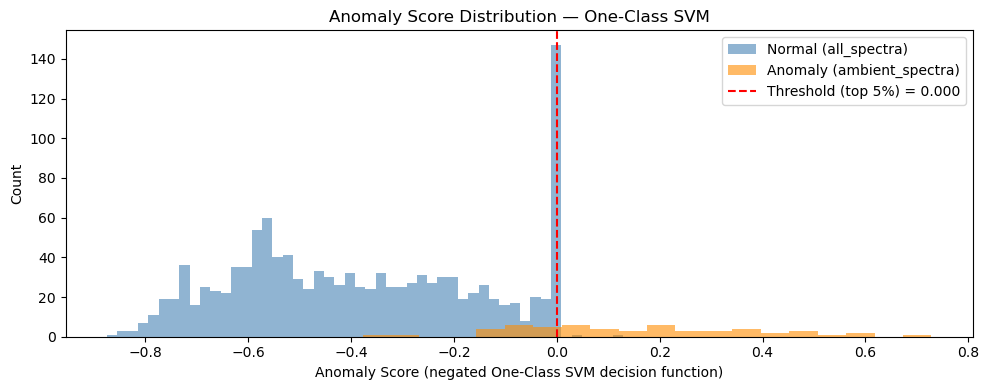

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

# Plot score distributions for both classes
ax.hist(scores_normal,  bins=50, alpha=0.6, color='steelblue',  label='Normal (all_spectra)')
ax.hist(scores_anomaly, bins=20, alpha=0.6, color='darkorange', label='Anomaly (ambient_spectra)')

# Draw the decision threshold
ax.axvline(threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold (top {THRESHOLD_PERCENTILE}%) = {threshold:.3f}')

ax.set_xlabel('Anomaly Score (negated One-Class SVM decision function)')
ax.set_ylabel('Count')
ax.set_title('Anomaly Score Distribution — One-Class SVM')
ax.legend()
plt.tight_layout()
plt.show()

**Results:** *(run the cell and interpret the plot here)*

## 8. Evaluate Performance

Predictions are made by comparing each sample's anomaly score against the threshold. Standard classification metrics are then used to measure performance.

- **Label convention:** `0` = normal, `1` = anomaly
- **Precision** — of all samples flagged as anomalies, how many actually were?
- **Recall** — of all actual anomalies, how many did the model catch?
- **F1** — harmonic mean of precision and recall
- **ROC-AUC** — overall ability to rank anomalies above normal samples (1.0 = perfect, 0.5 = random)

In [8]:
# Combine scores and true labels for evaluation
# 0 = normal, 1 = anomaly
all_scores  = np.concatenate([scores_normal, scores_anomaly])
true_labels = np.concatenate([
    np.zeros(len(scores_normal)),   # normal samples labeled 0
    np.ones(len(scores_anomaly))    # anomaly samples labeled 1
])

# Predict: score above threshold → anomaly (1), otherwise normal (0)
pred_labels = (all_scores > threshold).astype(int)

# Compute ROC-AUC using raw scores (threshold-independent)
roc_auc = roc_auc_score(true_labels, all_scores)

print(f'ROC-AUC Score : {roc_auc:.4f}\n')
print('Classification Report:')
print(classification_report(true_labels, pred_labels, target_names=['Normal', 'Anomaly']))

ROC-AUC Score : 0.9435

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.95      0.97      1215
     Anomaly       0.39      0.71      0.50        55

    accuracy                           0.94      1270
   macro avg       0.69      0.83      0.74      1270
weighted avg       0.96      0.94      0.95      1270



**Results:** *(run the cell and interpret the output here)*

## 9. Confusion Matrix

The confusion matrix breaks down predictions into correct and incorrect categories:

|  | Predicted Normal | Predicted Anomaly |
|--|--|--|
| **Actually Normal** | True Negative (TN) | False Positive (FP) |
| **Actually Anomaly** | False Negative (FN) | True Positive (TP) |

For anomaly detection, **False Negatives (FN)** are the most costly — these are real anomalies the model missed.

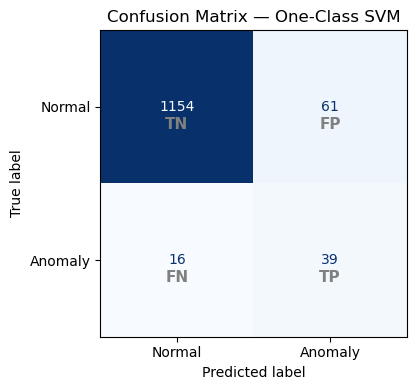

In [9]:
# Compute and display the confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — One-Class SVM')

# Label each cell with TP, TN, FP, FN
labels = [['TN', 'FP'],
          ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'\n\n{labels[i][j]}', ha='center', va='center',
                fontsize=11, fontweight='bold', color='gray')

plt.tight_layout()
plt.show()

**Results:** *(run the cell and interpret the confusion matrix here)*

## 10. ROC Curve

The ROC curve plots the **True Positive Rate** (anomalies correctly caught) against the **False Positive Rate** (normal samples incorrectly flagged) across all possible thresholds.

- A curve hugging the top-left corner = excellent model
- A diagonal line = random guessing (AUC = 0.5)

This is useful because it shows performance independent of the threshold you chose.

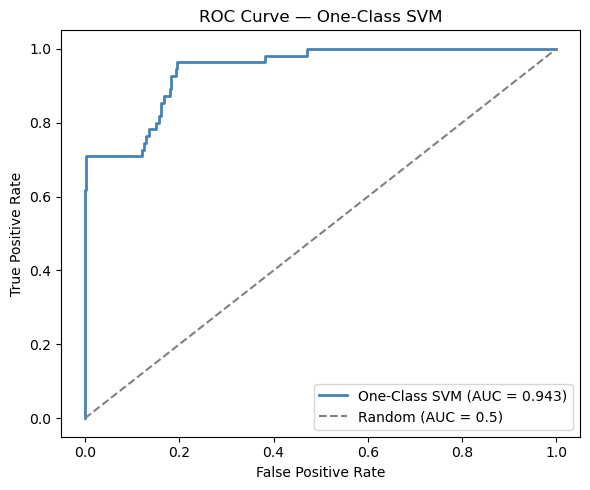

In [10]:
# Compute the ROC curve across all thresholds
fpr, tpr, _ = roc_curve(true_labels, all_scores)

fig, ax = plt.subplots(figsize=(6, 5))

# Plot the One-Class SVM ROC curve
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'One-Class SVM (AUC = {roc_auc:.3f})')

# Plot the random baseline
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — One-Class SVM')
ax.legend()
plt.tight_layout()
plt.show()

**Results:** *(run the cell and interpret the ROC curve here)*